# Advanced Statistics Problems Notebook

This is the notebook containing the problems and solutions from problems.md. As per the guidelines I will follow the Python coding standards and guidelines such as PEP8. The only packages that can be used are contained below as per requirements.txt in the problems brief

## Problem 1: Extending the Lady Tasting Tea

Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.

(applied-statistics/assessment
/problems.md Ian McLoughlan)

In [44]:
# Mathematical functions from the standard library
# https://docs.python.org/3/library/math.html
import math

# Show the different ways of picking no_cups_milk_first from no_cups
import itertools

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
from itertools import permutations, combinations

# Random Selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/user/absolute_beginners.html
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# Statistical functions.
# https://docs.scipy.org/doc/scipy/reference/stats.html
import scipy.stats as stats

# statistical models
# https://www.statsmodels.org/stable/index.html
# import statsmodels as sm

# Statistical plots
# https://seaborn.pydata.org/
import seaborn as sns

![Beverage Animation](https://cdn.pixabay.com/animation/2022/12/05/07/21/07-21-38-732_512.gif)

### Initial experiment: Lady tasting Tea

In the design of experiments in statistics, the lady tasting tea is a randomized experiment devised by Ronald Fisher and reported in his book The Design of Experiments (1935).[1] The experiment is the original exposition of Fisher's notion of a null hypothesis, which is "never proved or established, but is possibly disproved, in the course of experimentation".[2][3]

The example is loosely based on an event in Fisher's life. The woman in question, phycologist Muriel Bristol, claimed to be able to tell whether the tea or the milk was added first to a cup. Her future husband, William Roach, suggested that Fisher give her eight cups, four of each variety, in random order.[4] One could then ask what the probability was for her getting the specific number of cups she identified correct (in fact all eight), but just by chance.

Fisher's description is less than 10 pages in length and is notable for its simplicity and completeness regarding terminology, calculations and design of the experiment.[5] The test used was Fisher's exact test.

The experiment provides a subject with eight randomly ordered cups of tea – four prepared by pouring milk and then tea, four by pouring tea and then milk. The subject attempts to select the four cups prepared by one method or the other, and may compare cups directly against each other as desired. The method employed in the experiment is fully disclosed to the subject.

The null hypothesis is that the subject has no ability to distinguish the teas. In Fisher's approach, there was no alternative hypothesis,[2] unlike in the Neyman–Pearson approach.

The test statistic is a simple count of the number of successful attempts to select the four cups prepared by a given method. The distribution of possible numbers of successes, assuming the null hypothesis is true, can be computed using the number of combinations. Using the combination formula, with $n=8$ total cups and $k=4$ cups chosen, there are:

$$
{\binom {8}{4}}={\frac {8!}{4!(8-4)!}}=70
$$

possible combinations.

https://en.wikipedia.org/wiki/Lady_tasting_tea

### Permutations and Combinations
In mathematics, a permutation of a set can mean one of two different things:

- An arrangement of its members in a sequence or linear order, or

- The act or process of changing the linear order of an ordered set.

https://en.wikipedia.org/wiki/Lady_tasting_tea

In mathematics, a combination is a selection of items from a set that has distinct members, such that the order of selection does not matter (unlike permutations)

https://en.wikipedia.org/wiki/Combination

A Permutation is an ordered combination

In [45]:
# Number of cups to use in experiment (as per instructions)
no_cups = 8

# number of cups of tea with milk in first
no_cups_milk_first = 4
# number of cups with tea in first
no_cups_tea_first = 4



### Math.comb(n,k)

https://docs.python.org/3/library/math.html#math.comb

Return the number of ways to choose k items from n items without repetition and without order. The order does not matter for this particular experiment and the same cup cannot be chosen twice.

Evaluates to:

 n! / (k! * (n - k)!) 
 
 when k<=n and evaluates to zero when k>n.


In [46]:
# Number of ways of selecting four cups from eight
ways = math.comb(no_cups, no_cups_milk_first)

# Show result
print("Number of ways of selecting four cups from eight:", ways)

Number of ways of selecting four cups from eight: 70


### Answer and explaination

Number of ways of selecting four cups from eight: 70

This corresponds to the original experiment conducted by Ronald Fisher.

Each cup is labeled 1, 2, 3, 4, 5, 6, 7 and 8. Ideally wew would use labels that would not have orders such as colour, shapes, animals etc so as to not influence the outcome.

Four cups to have milk in first are chosen randomly. eg 4, 6, 2 and 8. Note: we dont care about the order in this experiment.

There are four placeholders where we place the four cup labels _ _ _ _

For the first placeholder all 8 numbers are candidates to be picked. For the second placeholder the remaining 7 are candidates and so on. Note the order is not important. 

If the order was important the following would be used:

In [47]:
# Total number of possible outcomes
ways_ordered = 8*7*6*5

print("Number of ordered ways of selecting four cups from eight:", ways_ordered)

Number of ordered ways of selecting four cups from eight: 1680


In [48]:
# The cup labels
labels = list(range(no_cups))

# show
print("Cup labels:", labels)

Cup labels: [0, 1, 2, 3, 4, 5, 6, 7]


https://www.geeksforgeeks.org/python/python-itertools-combinations-function/

The combinations() function in Python, part of the itertools module, is used to generate all possible combinations of a specified length from a given iterable (like a list, string, or tuple). Unlike permutations, where the order does matter, combinations focus only on the selection of elements, meaning the order does not matter. It returns an iterator producing tuples, each representing a unique combination of the input elements

itertools is efficient when using small values as in this experiment. But as the values increase the computer will take longer to generate this. 

In [49]:
combs = list(itertools.combinations(labels, no_cups_milk_first))

# Show result
combs

# the result is a tuple.

[(0, 1, 2, 3),
 (0, 1, 2, 4),
 (0, 1, 2, 5),
 (0, 1, 2, 6),
 (0, 1, 2, 7),
 (0, 1, 3, 4),
 (0, 1, 3, 5),
 (0, 1, 3, 6),
 (0, 1, 3, 7),
 (0, 1, 4, 5),
 (0, 1, 4, 6),
 (0, 1, 4, 7),
 (0, 1, 5, 6),
 (0, 1, 5, 7),
 (0, 1, 6, 7),
 (0, 2, 3, 4),
 (0, 2, 3, 5),
 (0, 2, 3, 6),
 (0, 2, 3, 7),
 (0, 2, 4, 5),
 (0, 2, 4, 6),
 (0, 2, 4, 7),
 (0, 2, 5, 6),
 (0, 2, 5, 7),
 (0, 2, 6, 7),
 (0, 3, 4, 5),
 (0, 3, 4, 6),
 (0, 3, 4, 7),
 (0, 3, 5, 6),
 (0, 3, 5, 7),
 (0, 3, 6, 7),
 (0, 4, 5, 6),
 (0, 4, 5, 7),
 (0, 4, 6, 7),
 (0, 5, 6, 7),
 (1, 2, 3, 4),
 (1, 2, 3, 5),
 (1, 2, 3, 6),
 (1, 2, 3, 7),
 (1, 2, 4, 5),
 (1, 2, 4, 6),
 (1, 2, 4, 7),
 (1, 2, 5, 6),
 (1, 2, 5, 7),
 (1, 2, 6, 7),
 (1, 3, 4, 5),
 (1, 3, 4, 6),
 (1, 3, 4, 7),
 (1, 3, 5, 6),
 (1, 3, 5, 7),
 (1, 3, 6, 7),
 (1, 4, 5, 6),
 (1, 4, 5, 7),
 (1, 4, 6, 7),
 (1, 5, 6, 7),
 (2, 3, 4, 5),
 (2, 3, 4, 6),
 (2, 3, 4, 7),
 (2, 3, 5, 6),
 (2, 3, 5, 7),
 (2, 3, 6, 7),
 (2, 4, 5, 6),
 (2, 4, 5, 7),
 (2, 4, 6, 7),
 (2, 5, 6, 7),
 (3, 4, 5, 6),
 (3, 4, 5,

In [50]:
# Select four cups at random to put milk in first.
# https://docs.python.org/3/library/random.html
labels_milk = random.sample(labels, 4)

# sort 
labels_milk.sort()

# show
print("Cups with milk in first (randomly selected):", labels_milk)


Cups with milk in first (randomly selected): [0, 2, 5, 6]


In [51]:
# Turn labels_milk into a set for easier checking
# https://docs.python.org/3/tutorial/datastructures.html#sets
set_labels_milk = set(labels_milk)

print("Set of cups with milk in first:", set_labels_milk)

Set of cups with milk in first: {0, 2, 5, 6}


In [52]:
# Calculate the overlap between each element of combs and labels_milk
no_overlaps = []

for comb in combs:
    # turn comb into a set
    s1 = set(comb)

    #Turn labels_milk into a set
    s2 = set(labels_milk)
    
    # find overlap
    overlap = s1.intersection(s2)

    # Show the combination and the overlap
    print(comb, overlap, len(overlap))

    # Append overlap to no_overlaps
    no_overlaps.append(len(overlap))




(0, 1, 2, 3) {0, 2} 2
(0, 1, 2, 4) {0, 2} 2
(0, 1, 2, 5) {0, 2, 5} 3
(0, 1, 2, 6) {0, 2, 6} 3
(0, 1, 2, 7) {0, 2} 2
(0, 1, 3, 4) {0} 1
(0, 1, 3, 5) {0, 5} 2
(0, 1, 3, 6) {0, 6} 2
(0, 1, 3, 7) {0} 1
(0, 1, 4, 5) {0, 5} 2
(0, 1, 4, 6) {0, 6} 2
(0, 1, 4, 7) {0} 1
(0, 1, 5, 6) {0, 5, 6} 3
(0, 1, 5, 7) {0, 5} 2
(0, 1, 6, 7) {0, 6} 2
(0, 2, 3, 4) {0, 2} 2
(0, 2, 3, 5) {0, 2, 5} 3
(0, 2, 3, 6) {0, 2, 6} 3
(0, 2, 3, 7) {0, 2} 2
(0, 2, 4, 5) {0, 2, 5} 3
(0, 2, 4, 6) {0, 2, 6} 3
(0, 2, 4, 7) {0, 2} 2
(0, 2, 5, 6) {0, 2, 5, 6} 4
(0, 2, 5, 7) {0, 2, 5} 3
(0, 2, 6, 7) {0, 2, 6} 3
(0, 3, 4, 5) {0, 5} 2
(0, 3, 4, 6) {0, 6} 2
(0, 3, 4, 7) {0} 1
(0, 3, 5, 6) {0, 5, 6} 3
(0, 3, 5, 7) {0, 5} 2
(0, 3, 6, 7) {0, 6} 2
(0, 4, 5, 6) {0, 5, 6} 3
(0, 4, 5, 7) {0, 5} 2
(0, 4, 6, 7) {0, 6} 2
(0, 5, 6, 7) {0, 5, 6} 3
(1, 2, 3, 4) {2} 1
(1, 2, 3, 5) {2, 5} 2
(1, 2, 3, 6) {2, 6} 2
(1, 2, 3, 7) {2} 1
(1, 2, 4, 5) {2, 5} 2
(1, 2, 4, 6) {2, 6} 2
(1, 2, 4, 7) {2} 1
(1, 2, 5, 6) {2, 5, 6} 3
(1, 2, 5, 7) {2, 5} 2
(1, 2, 6

In [53]:
# Show the overlaps
print(no_overlaps)

[2, 2, 3, 3, 2, 1, 2, 2, 1, 2, 2, 1, 3, 2, 2, 2, 3, 3, 2, 3, 3, 2, 4, 3, 3, 2, 2, 1, 3, 2, 2, 3, 2, 2, 3, 1, 2, 2, 1, 2, 2, 1, 3, 2, 2, 1, 1, 0, 2, 1, 1, 2, 1, 1, 2, 2, 2, 1, 3, 2, 2, 3, 2, 2, 3, 2, 1, 1, 2, 2]


In [54]:
#count the number of times each overlap occurs.
counts = np.unique(no_overlaps, return_counts=True)

# show
print("Overlap counts:", counts)

Overlap counts: (array([0, 1, 2, 3, 4]), array([ 1, 16, 36, 16,  1]))


Overlap counts: (array([0, 1, 2, 3, 4]), array([ 1, 16, 36, 16,  1]))

This tells us that there is once in the 70 chances that none of the picks were correct, 16 chances that one cup is correct, 36 chances that two cups were correct (which is slightly over half), 16 chances that 3 cups were correct and one chance that all four cups are correctly picked.

Pascals triangle explains why this array looks like this.


### Pascal's Triangle

In mathematics, Pascal's triangle is an infinite triangular array of the binomial coefficients which play a crucial role in probability theory, combinatorics, and algebra.

The rows of Pascal's triangle are conventionally enumerated starting with row n=0 at the top (the 0th row). The entries in each row are numbered from the left beginning with k=0 and are usually staggered relative to the numbers in the adjacent rows. The triangle may be constructed in the following manner: In row 0 (the topmost row), there is a unique nonzero entry 1. Each entry of each subsequent row is constructed by adding the number above and to the left with the number above and to the right, treating blank entries as 0. For example, the initial number of row 1 (or any other row) is 1 (the sum of 0 and 1), whereas the numbers 1 and 3 in row 3 are added to produce the number 4 in row 4.

![Pascal's Triangle Visualization](https://upload.wikimedia.org/wikipedia/commons/0/0d/PascalTriangleAnimated2.gif)

https://en.wikipedia.org/wiki/Pascal%27s_triangle



<BarContainer object of 5 artists>

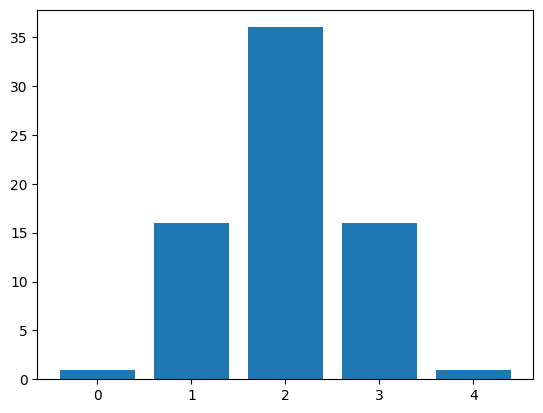

In [55]:
# Create a figure.
fig, ax = plt.subplots()

# Plot a bar chart of the counts
ax.bar(counts[0], counts[1])

### Hypothesis Testing in Statistics

Hypothesis testing is a form of statistical inference that uses data from a sample to draw conclusions about a population parameter or a population probability distribution. First, a tentative assumption is made about the parameter or distribution. This assumption is called the null hypothesis and is denoted by $H_0$. An alternative hypothesis (denoted $H_a$), which is the opposite of what is stated in the null hypothesis, is then defined. The hypothesis-testing procedure involves using sample data to determine whether or not $H_0$ can be rejected. If $H_0$ is rejected, the statistical conclusion is that the alternative hypothesis $H_a$ is true.

https://www.britannica.com/science/statistics/Hypothesis-testing

When the hypothesis statement is written, it has to be more than a guess. To generate a solid hypothesis, first ask these questions:

1. What is the connection between the hypothesis and the research topic?
2. Is the hypothesis testable?
3. What potential explanations or justifications of the hypothesis can be explored?
4. What are the counter-arguments to the hypothesis?
5. Does the hypothesis include an independent as well as a dependent variable?

Exploring these questions will help you make sure that the hypothesis is solid and, if not, where its weaknesses lie. It is important to go through these steps first so that the researcher is well-positioned to conduct the research.

A testable hypothesis is not a simple statement. It is rather an informed, predictive statement that provides a clear introduction to a study, its goals, and the possible outcomes. There are some important things to consider when building a compelling, testable hypothesis:

1. Clearly state the prediction you are proposing. Make sure that the hypothesis clearly defines the topic and the focus of the study.
    - Identifying the cups with milk in first and the cups with tea in first.
2. Aim to write the hypothesis as an if-then statement.
   - Follow this template: If a specific action is taken, then a certain outcome is expected.
   - Example: If the lady can identify which cups had milk added first, then she will be able to pick the correct cups (i.e., she can tell the difference).
3. Define the variables.
   - **Independent variables**: The ones that are manipulated, controlled, or changed in the study. Independent variables are isolated from other factors of the study.
   - **Dependent variables**: Dependent on other factors of the study and are influenced by what happens to the independent variables.
4. Make sure that the proposed hypothesis has results that can be reproduced.


https://owl.excelsior.edu/research/research-hypotheses/formulating-strong-hypotheses/

### The Null Hypothetis

A null hypothesis, denoted by $H_0$, posits a negative statement to support the researcher’s findings that there is no relationship between two variables or that any findings are the result of mere chance.

https://owl.excelsior.edu/research/research-hypotheses/types-of-research-hypotheses/#:~:text=Simple%20Hypothesis,more%20independent%20and%20dependent%20variables.

- The lady has no special powers to tell the difference between cups of tea with milk in first and cups of tea with tea in first.

- The lady is selecting the four cups from the eight cups at random.

### Alternative Hypothesis

An alternative hypothesis, denoted by $H_1$ or $H_a$, challenges the null hypothesis and states that there is a relationship between the two variables of the study and that the results are significant to the research topic.

https://owl.excelsior.edu/research/research-hypotheses/types-of-research-hypotheses/#:~:text=Simple%20Hypothesis,more%20independent%20and%20dependent%20variables.

- The lady can tell the difference.

### Evidence

If the lady is picking four cups at random what is the probability that she picks the correct four?


In [56]:
# Probability that she randomly selects the four correct cups
1/70

0.014285714285714285

In [57]:
# The probablity that the lady randomly selects at least three correct cups.
(16+1)/70

0.24285714285714285

### Type I errors, Type II Errors and Power

### Type I and Type II errors
Type I error, or a false positive, is the incorrect rejection of a true null hypothesis in statistical hypothesis testing. A type II error, or a false negative, is the incorrect failure to reject a false null hypothesis.

Type I errors can be thought of as errors of commission, in which the status quo is incorrectly rejected in favour of new, misleading information.

Type II errors can be thought of as errors of omission, in which a misleading status quo is allowed to remain due to failures in identifying it as such.


Knowledge of type I errors and type II errors is applied widely in fields of in medical science, biometrics and computer science. Minimising these errors is an object of study within statistical theory, though complete elimination of either is impossible when relevant outcomes are not determined by known, observable, causal processes.

https://en.wikipedia.org/wiki/Type_I_and_type_II_errors

### Power
Statistical power, or sensitivity, is the likelihood of a significance test detecting an effect when there actually is one.

A true effect is a real, non-zero relationship between variables in a population. An effect is usually indicated by a real difference between groups or a correlation between variables.

High power in a study indicates a large chance of a test detecting a true effect. Low power means that your test only has a small chance of detecting a true effect or that the results are likely to be distorted by random and systematic error.

Power is mainly influenced by sample size, effect size, and significance level. A power analysis can be used to determine the necessary sample size for a study.

https://www.scribbr.com/statistics/statistical-power/#:~:text=Statistical%20power%2C%20or%20sensitivity%2C%20is,sample%20size%20for%20a%20study.

### Expantion of the experiment

As per the assignment brief, extending the original experiment to 12 cups: 8 tea-first and 4 milk-first, and analyze the probability of correctly identifying all cups by chance.

**Extended Experiment Setup:**
- Total cups: 12 (instead of 8)
- Tea-first cups: 8 (instead of 4)
- Milk-first cups: 4 (same as original) 

**Probability Calculation:**

Using the combination formula, the total number of ways to select 4 cups from 12 is:

$$\binom{12}{4} = \frac{12!}{4!(12-4)!} = \frac{12!}{4! \cdot 8!} = 495$$

In [58]:
# code for above
# Number of cups to use in experiment (as per instructions)
no_cups = 12

# number of cups of tea with milk in first
no_cups_milk_first = 8
# number of cups with tea in first
no_cups_tea_first = 4

# Number of ways of selecting four cups from twelve
ways = math.comb(no_cups, no_cups_milk_first)

# Show result
print("Number of ways of selecting four cups from twelve:", ways)

Number of ways of selecting four cups from twelve: 495


This means there are 495 possible ways to select 4 cups from the 12 available cups.

**Probability of Success by Chance:**
- In the original experiment: $P = \frac{1}{70} \approx 0.0143$ (1.43%)
- In the extended experiment: $P = \frac{1}{495} \approx 0.0020$ (0.20%)

In [59]:
# code for above
# Probability that she randomly selects the four correct cups
1/495


0.00202020202020202

### Analysis

**Key Findings:**

1. **Dramatically Lower Probability:** The probability of correctly identifying all 4 milk-first cups by pure chance drops from 1.43% to 0.20% 

2. **Stronger Evidence Against Null Hypothesis:** With such a low probability (0.20%), if the participant correctly identifies all cups, this would provide much stronger evidence against the null hypothesis (that they're guessing randomly).

3. **P-value Threshold Implications:** 
    - The original experiment had a p-value of 0.0143, which is less than the conventional α = 0.05 threshold
    - The extended experiment would have a p-value of 0.0020, which is even more significant

**Statistical Interpretation:**

The extended design makes the test more stringent and powerful. The extremely low probability (0.20%) means that if someone correctly identifies all 4 milk-first cups, we can be even more confident that they have genuine discriminatory ability rather than just being lucky.

**Recommendation on P-value Threshold:**

Rather than relaxing the p-value threshold, the extended experiment actually allows us to maintain or even strengthen our confidence in rejecting the null hypothesis. The 0.0020 probability provides strong evidence against random guessing, making this a more robust experimental design for detecting true discriminatory ability.

![Normal Distribution Animation](https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExYXg3NWoxbmlidzg3dnp6bGRpM2g2aDBlaDVpd3JxNHk4NWZtanV3MCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/a8TIlyVS7JixO/giphy.gif)

## Problem 2: Normal Distribution

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

(applied-statistics/assessment
/problems.md Ian McLoughlan)

In [60]:
# Flip a single coin
# https://numpy.org/doc/2.1/reference/random/generated/numpy.random.binomial.html
np.random.binomial(1, 0.5)

0

Samples are drawn from a binomial distribution with specified parameters, n trials and p probability of success where n an integer >= 0 and p is in the interval [0,1]. (n may be input as a float, but it is truncated to an integer in use)

https://numpy.org/doc/2.1/reference/random/generated/numpy.random.binomial.html

The first number ie 1 is the number of the items. In this case it is the number of coins. As there is the same chance of heads as tails or success or failure that is how we get the 0.5. (0.5 + 0.5 = 1) we have not specified how many times the coin was to be flipped. Below we specify that the coin was to be flipped 1000 times. 

In [61]:
# flip a single coin several times
flips = np.random.binomial(1, 0.5, size=1000)

# Show
flips


array([0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,

In the above cell, we can see all the times heads (1) was selected and the number of times tails (0) was selected. In large samples such as this, it is difficult to determine the exact counts of heads and tails by inspection. By using the `sum` function, the number of heads can be calculated (since heads is denoted by 1). The number of tails can then be derived by subtracting the number of heads from the total number of flips.

In [62]:
# Count heads
# https://www.datacamp.com/doc/numpy/sum
heads = flips.sum()

# Show
heads


np.int64(509)

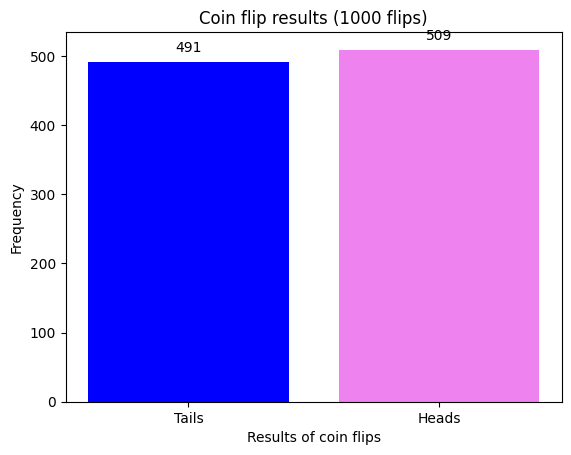

In [63]:
#https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/

# Create a blank plot
fig, ax = plt.subplots()

# create a bar chart with custom colors
ax.bar([0, 1], [1000-heads, heads], color=['blue', 'violet'])

# add x labels
ax.set_xticks([0, 1], labels=["Tails", "Heads"])

# Add title
ax.set_title("Coin flip results (1000 flips)")

# Add axis labels
ax.set_xlabel("Results of coin flips")
ax.set_ylabel("Frequency")

# Add numerical values on top of the bars
for i, value in enumerate([1000-heads, heads]):
    ax.text(i, value + 10, str(value), ha='center', va='bottom')

The reason for using a bar chart as opposed to a histogram is that histograms are used for continuous probability distributions, while bar charts are typically used for discrete probability distributions.

A **probability distribution** is a mathematical description of the probabilities of events, subsets of the sample space. The sample space, often represented in notation by $\Omega$, is the set of all possible outcomes of a random phenomenon being observed. The sample space may be any set: a set of real numbers, a set of descriptive labels, a set of vectors, or a set of arbitrary non-numerical values. For example, the sample space of a coin flip could be $\Omega = \{\text{heads}, \text{tails}\}$.

**Continuous probability distributions** can be described by means of the cumulative distribution function, which describes the probability that the random variable is no larger than a given value (i.e., $P(X \leq x)$ for some $x$).

A **discrete probability distribution** is the probability distribution of a random variable that can take on only a countable number of values (almost surely). This means that the probability of any event $E$ can be expressed as a (finite or countably infinite) sum:

$$
P(X \in E) = \sum_{\omega \in A \cap E} P(X = \omega),
$$

where $A$ is a countable set with $P(X \in A) = 1$. Thus, the discrete random variables (i.e., random variables whose probability distribution is discrete) are exactly those with a probability mass function:

$$
p(x) = P(X = x).
$$

https://en.wikipedia.org/wiki/Probability_distribution

In [64]:
# flip two coins several times
twoflips = np.random.binomial(2, 0.5, size=1000)

# Show
twoflips

array([0, 0, 2, 2, 0, 2, 0, 2, 0, 1, 1, 1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 2, 0, 1, 2, 1, 1, 0, 1, 2, 2, 2, 2, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 2, 0, 0, 2, 1, 1, 0, 0,
       1, 0, 1, 1, 2, 1, 1, 2, 0, 1, 1, 2, 1, 0, 1, 0, 1, 0, 1, 2, 1, 1,
       1, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 2, 1, 0, 0, 1, 2, 1, 1, 0,
       0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 0, 0, 2, 2, 2, 1, 2,
       2, 0, 2, 1, 1, 1, 1, 1, 1, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2,
       2, 2, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 2, 0, 1, 1, 2, 1, 2, 1, 0, 1,
       2, 2, 1, 2, 1, 0, 1, 2, 2, 0, 1, 2, 1, 2, 0, 2, 1, 0, 1, 1, 2, 1,
       2, 2, 1, 0, 1, 1, 0, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 2,
       0, 0, 2, 1, 0, 1, 2, 0, 0, 2, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 0,
       2, 1, 0, 1, 1, 0, 2, 1, 1, 0, 1, 0, 1, 0, 1, 2, 2, 1, 0, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 1, 2, 2, 0, 1, 0, 1, 0, 1, 2, 1, 0, 2, 1, 1, 2,
       1, 1, 2, 2, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 2,

This the probability of flipping two coins. Do we get 0 heads? 1 head? or two heads? The chances are still 50/50 or 0.5 per coin. and each coin is flipped 1000 times. ie 2000 in total as there are two coins.

In [65]:
# count the number of times each outcome or value occurs.
# https://numpy.org/doc/stable/reference/generated/numpy.unique.html#main-content
uniques, counts = np.unique(twoflips, return_counts=True)

# Show
uniques, counts

(array([0, 1, 2]), array([253, 507, 240]))

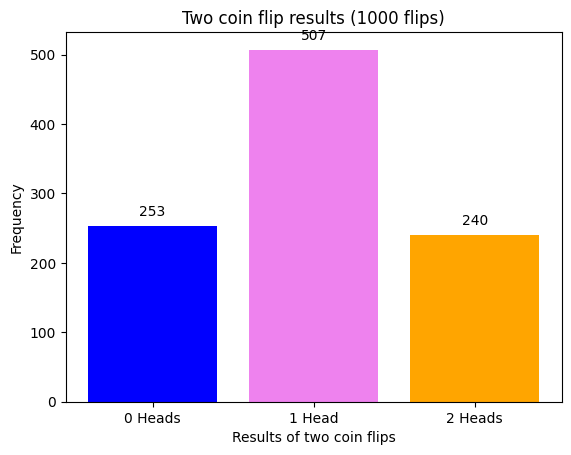

In [66]:
# create a blank plot
fig, ax = plt.subplots()

# create a bar chart with custom colors
ax.bar(uniques, counts, color=['blue', 'violet', 'orange'])

# set x ticks
ax.set_xticks(uniques, labels=["0 Heads", "1 Head", "2 Heads"])

# Add title
ax.set_title("Two coin flip results (1000 flips)")

# Add axis labels
ax.set_xlabel("Results of two coin flips")
ax.set_ylabel("Frequency") 
# Add numerical values on top of the bars
for i, value in enumerate(counts):
    ax.text(uniques[i], value + 10, str(value), ha='center', va='bottom')
    

### Bessel's correction

In statistics, Bessel's correction is the use of n − 1 instead of n in the formula for the sample variance and sample standard deviation,[1] where n is the number of observations in a sample. This method corrects the bias in the estimation of the population variance. It also partially corrects the bias in the estimation of the population standard deviation. However, the correction often increases the mean squared error in these estimations. This technique is named after Friedrich Bessel.

In estimating the population variance from a sample when the population mean is unknown, the uncorrected sample variance is the mean of the squares of deviations of sample values from the sample mean (i.e., using a multiplicative factor 1/n). In this case, the sample variance is a biased estimator of the population variance. Multiplying the uncorrected sample variance by the factor

$$

{\displaystyle {\frac {n}{n-1}}}
$$
gives an unbiased estimator of the population variance. In some literature,[2][3] the above factor is called Bessel's correction.

One can understand Bessel's correction as the degrees of freedom in the residuals vector (residuals, not errors, because the population mean is unknown):
$$
{\displaystyle (x_{1}-{\overline {x}},\,\dots ,\,x_{n}-{\overline {x}}),}
$$ where $${\displaystyle {\overline {x}}}$$ is the sample mean. While there are n independent observations in the sample, there are only n − 1 independent residuals, as they sum to 0. For a more intuitive explanation of the need for Bessel's correction, see § Source of bias.

Generally Bessel's correction is an approach to reduce the bias due to finite sample size. Such finite-sample bias correction is also needed for other estimates like skew and kurtosis, but in these the inaccuracies are often significantly larger. To fully remove such bias it is necessary to do a more complex multi-parameter estimation. For instance a correct correction for the standard deviation depends on the kurtosis (normalized central 4th moment), but this again has a finite sample bias and it depends on the standard deviation, i.e., both estimations have to be merged.

https://en.wikipedia.org/wiki/Bessel%27s_correction



### Two coins but keeping individual outcomes.

In the above cells, we were able to flip two coins. The results were 0 heads (0), 1 head (1) or two heads (2). This, however did not differentiate which coin when flipped returned heads. Below we can identify which coin returned the heads. 

In [67]:
twoflipsind = np.random.binomial(1, 0.5, size=(1000, 2))

# show
twoflipsind

array([[1, 1],
       [0, 0],
       [1, 0],
       ...,
       [0, 0],
       [1, 0],
       [1, 1]], shape=(1000, 2))

In [68]:
# count the number of times each outcome occurs
uniques, counts = np.unique(twoflipsind, axis=0, return_counts=True)

# show
uniques, counts

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([257, 199, 283, 261]))

In [69]:
# pyplot does not like unique being a two-dimentional array
uniques = [str(i) for i in uniques]


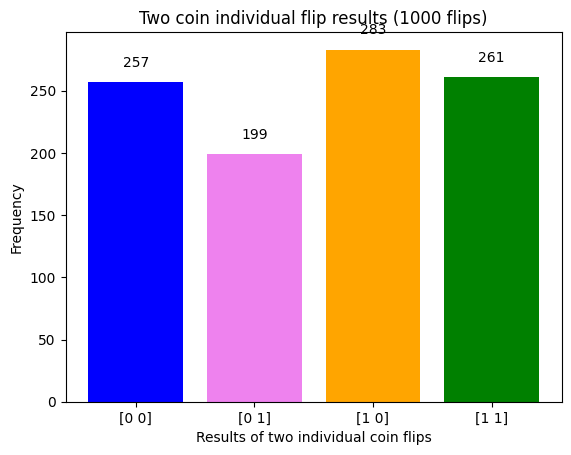

In [70]:
# create a blank plot
fig, ax = plt.subplots()

# create a bar chart with custom colors
ax.bar(range(len(uniques)), counts, color=['blue', 'violet', 'orange', 'green'])

# set x ticks
ax.set_xticks(range(len(uniques)), labels=uniques)

# add title
ax.set_title("Two coin individual flip results (1000 flips)")

# add axis labels
ax.set_xlabel("Results of two individual coin flips")
ax.set_ylabel("Frequency")
# add numerical values on top of the bars
for i, value in enumerate(counts):
    ax.text(i, value + 10, str(value), ha='center', va='bottom')
    


[0,0] is two tails. [0,1] is the first coin is tails and the second is heads. [1,0] the first coin is heads while the second is tails. [1,1] both coins are heads.

### Probability Density Function

In probability theory and statistics, a normal distribution or Gaussian distribution is a type of continuous probability distribution for a real-valued random variable. The general form of its probability density function is:

$$
f(x) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}.
$$

The parameter $\mu$ is the mean or expectation of the distribution (and also its median and mode), while the parameter $\sigma^2$ is the variance. The standard deviation of the distribution is $\sigma$ (sigma). A random variable with a Gaussian distribution is said to be normally distributed and is called a normal deviate.

Normal distributions are important in statistics and are often used in the natural and social sciences to represent real-valued random variables whose distributions are not known. Their importance is partly due to the central limit theorem, which states that, under some conditions, the average of many samples (observations) of a random variable with finite mean and variance is itself a random variable whose distribution converges to a normal distribution as the number of samples increases. Therefore, physical quantities that are expected to be the sum of many independent processes, such as measurement errors, often have distributions that are nearly normal.

Moreover, Gaussian distributions have some unique properties that are valuable in analytic studies. For instance, any linear combination of a fixed collection of independent normal deviates is a normal deviate. Many results and methods, such as propagation of uncertainty and least squares parameter fitting, can be derived analytically in explicit form when the relevant variables are normally distributed.

A normal distribution is sometimes informally called a bell curve.

![Normal Distribution Curve](https://upload.wikimedia.org/wikipedia/commons/thumb/7/74/Normal_Distribution_PDF.svg/1200px-Normal_Distribution_PDF.svg.png)

https://en.wikipedia.org/wiki/Normal_distribution

In probability theory, a probability density function (PDF), density function, or density of an absolutely continuous random variable, is a function whose value at any given sample (or point) in the sample space (the set of possible values taken by the random variable) can be interpreted as providing a relative likelihood that the value of the random variable would be equal to that sample. Probability density is the probability per unit length. While the absolute likelihood for a continuous random variable to take on any particular value is zero (given there is an infinite set of possible values to begin with), the value of the PDF at two different samples can be used to infer how much more likely it is that the random variable would be close to one sample compared to the other sample.

More precisely, the PDF is used to specify the probability of the random variable falling within a particular range of values, as opposed to taking on any one value. This probability is given by the integral of a continuous variable's PDF over that range, where the integral is the nonnegative area under the density function between the lowest and greatest values of the range. The PDF is nonnegative everywhere, and the area under the entire curve is equal to one, such that the probability of the random variable falling within the set of possible values is 100%.

https://en.wikipedia.org/wiki/Probability_density_function


In [71]:
def f(x, mu=0.0, sigma=1.0):

# the normalisation constant
# https://numpy.org/doc/2.2/reference/generated/numpy.sqrt.html
    norm = 1.0 / np.sqrt(2.0 * np.pi * sigma**2)

    # f(x)
    return norm * np.exp(-(x - mu)**2 / (2.0 * sigma**2))

$$
f(x) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}.
$$

this equation is represented in code by:

 norm = 1.0 / np.sqrt(2.0 * np.pi * sigma**2)  for the first part of the equation and 

 norm * np.exp(-(x - mu)**2 / (2.0 * sigma**2)) for the second part as seen in the above cell.

When x is 0 

In [72]:
# Test the function
f(0.0)

np.float64(0.3989422804014327)

In [73]:
# create an x range
x = np.linspace(-5.0, 5.0, 1001)

# get the y values
y = f(x)

# Show
x, y

(array([-5.  , -4.99, -4.98, ...,  4.98,  4.99,  5.  ], shape=(1001,)),
 array([1.48671951e-06, 1.56286711e-06, 1.64275059e-06, ...,
        1.64275059e-06, 1.56286711e-06, 1.48671951e-06], shape=(1001,)))

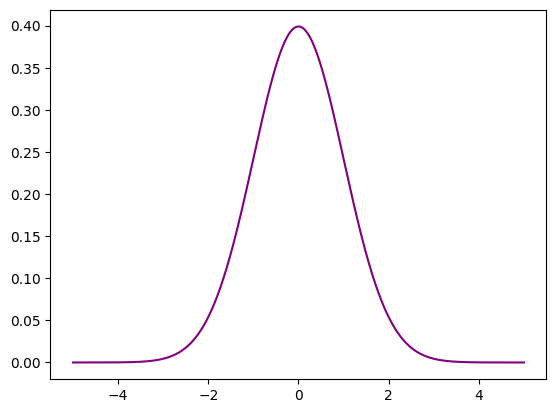

In [74]:
# create an empty plot.
fig, ax = plt.subplots()

# Plot the function.
ax.plot(x, y, "purple")


Text(0, 0.5, 'Proportion of outcomes')

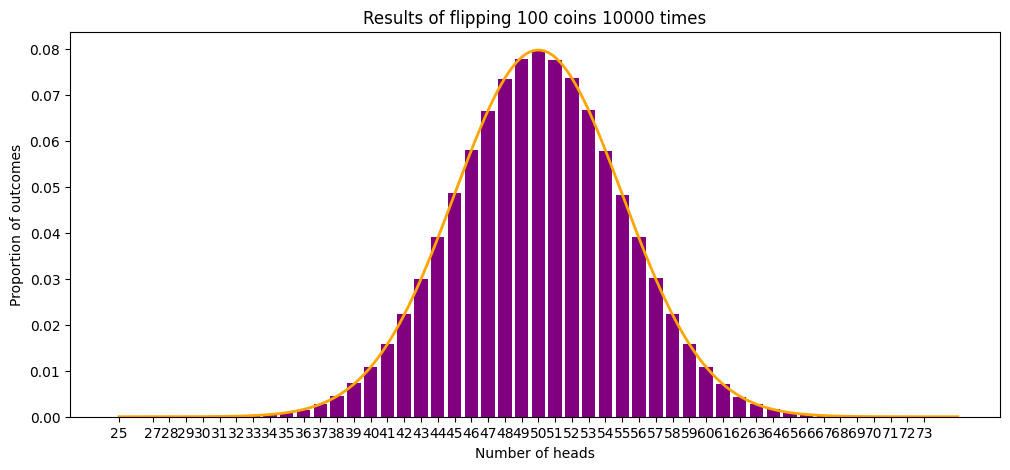

In [75]:
#Number of coins to flip.
n = 100

# Number of times to flip the coins.
k = 10000 * n

# Probability of heads
p = 0.5

# Flip two coins several times.
nflips = np.random.binomial(n, p, size=k)

# Count the number of times each outcome or value occurs.
uniques, counts = np.unique(nflips, return_counts=True)

# Create a blank plot
fig, ax = plt.subplots(figsize=(12, 5))

# create a bar chart with custom colors
# Previously the counts were compared, now we want the proportion of k occured.
# the proportion rather than the total number
# https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html
ax.bar(uniques, counts / k, color='purple')

# Create an x range
x = np.linspace(25, 75, 1001)

# Get the y values
# mu=n*p is where the normal is centred
# sigma=np.sqrt(n*p*(1-p)) is the standard deviation of the binomial distribution
# which is used to set the width of the normal distribution.
# https://numpy.org/doc/2.2/reference/generated/numpy.sqrt.html
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
# https://numpy.org/doc/stable/reference/generated/numpy.pi.html
y = f(x, mu=n*p, sigma=np.sqrt(n*p*(1-p)))

# Plot the function.
ax.plot(x, y, "orange", linewidth=2)

# set x ticks
ax.set_xticks(uniques)

# Add title
ax.set_title(f"Results of flipping {n} coins {k//n} times")

# Add axis labels
ax.set_xlabel("Number of heads")
ax.set_ylabel("Proportion of outcomes")


### Generating Data


https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

In [76]:
# Generate a random normal sample.
# https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html
data = np.random.normal(size=6)

# Show
data

array([ 0.03241918,  0.75643873, -0.73060319,  0.00250765,  1.05179391,
        0.8596833 ])

random.normal(loc=0.0, scale=1.0, size=None)

<u>Parameters</u>
:

<i>loc:</i>

float or array_like of floats
Mean (“centre”) of the distribution.

<i>scale:</i>

float or array_like of floats
Standard deviation (spread or “width”) of the distribution. Must be non-negative.

<i>size:</i>

int or tuple of ints, optional
Output shape. If the given shape is, e.g., (m, n, k), then m * n * k samples are drawn. If size is None (default), a single value is returned if loc and scale are both scalars. Otherwise, np.broadcast(loc, scale).size samples are drawn.

In ther above cell we do not have to specify the loc or scale as it is preset. If we however change either one both must be specified

https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

<BarContainer object of 6 artists>

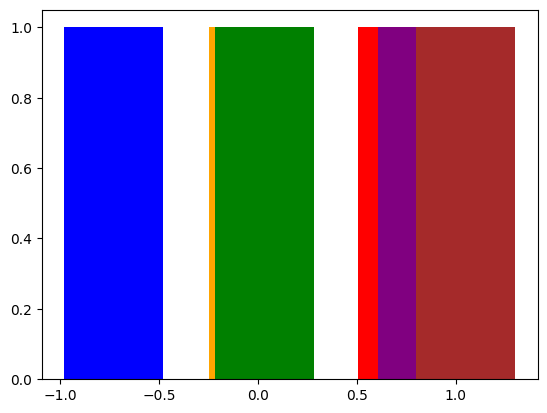

In [77]:
# create a blank plot
fig, ax = plt.subplots()

# Count unique values and their counts
uniques, counts = np.unique(data, return_counts=True)

# Create a bar chart with colours.
ax.bar(uniques, counts, width=0.5, color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])     


The above bar chart illustrates why bar charts are inappropriate when plotting continuous data. Data using a discrete probability distribution such as flipping a coin above, generated a 0 or a 1 (I.e. heads or tails.) are suited to a bar graph. Continuous probability distribution however, are better to a histogram. A bar chart is when there are known jumps in the X axis. There are no values, for example between 0 and 1. While a histogram is used whenthere is a continuous spectrum between the different points on the X axis or the whole X axis. 

In [78]:
# https://numpy.org/doc/2.2/reference/generated/numpy.histogram.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
data = np.random.normal(loc=0.0, scale=1.0, size=100000)

# show
data

array([-0.06421305, -0.59069783,  0.9034635 , ..., -1.43273554,
       -0.08249432,  0.24245511], shape=(100000,))

(array([1.000e+00, 1.700e+01, 3.500e+01, 6.700e+01, 1.530e+02, 3.050e+02,
        5.650e+02, 1.056e+03, 1.730e+03, 2.615e+03, 3.874e+03, 5.335e+03,
        6.752e+03, 8.333e+03, 9.236e+03, 9.934e+03, 9.739e+03, 9.259e+03,
        8.190e+03, 6.892e+03, 5.275e+03, 3.893e+03, 2.768e+03, 1.712e+03,
        1.016e+03, 6.040e+02, 3.380e+02, 1.620e+02, 8.700e+01, 3.000e+01,
        1.700e+01, 2.000e+00]),
 array([-4.  , -3.75, -3.5 , -3.25, -3.  , -2.75, -2.5 , -2.25, -2.  ,
        -1.75, -1.5 , -1.25, -1.  , -0.75, -0.5 , -0.25,  0.  ,  0.25,
         0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,  2.25,  2.5 ,
         2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ]),
 <BarContainer object of 32 artists>)

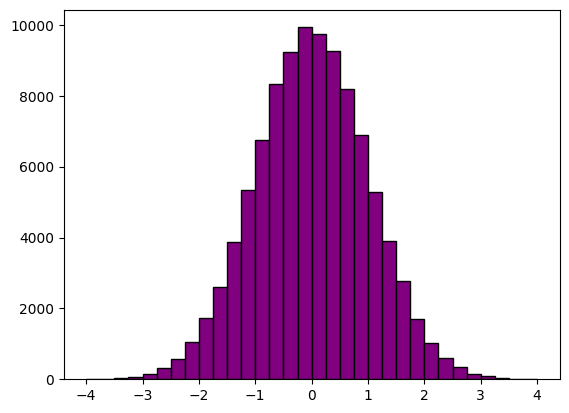

In [79]:
# create a blank plot.
fig, ax = plt.subplots()

# create a histogram
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
ax.hist(data, color='purple', edgecolor='black', bins=np.linspace(-4, 4, 33))
# bins are chunks of the X axis.

### Sampling Distribution

In statistics, a sampling distribution or finite-sample distribution is the probability distribution of a given random-sample-based statistic. For an arbitrarily large number of samples where each sample, involving multiple observations (data points), is separately used to compute one value of a statistic (for example, the sample mean or sample variance) per sample, the sampling distribution is the probability distribution of the values that the statistic takes on. In many contexts, only one sample (i.e., a set of observations) is observed, but the sampling distribution can be found theoretically.

Sampling distributions are important in statistics because they provide a major simplification en route to statistical inference. More specifically, they allow analytical considerations to be based on the probability distribution of a statistic, rather than on the joint probability distribution of all the individual sample values.

https://en.wikipedia.org/wiki/Sampling_distribution

### Expanding above.
As per the assessment brief "Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased."

Text(0, 0.5, 'Proportion of outcomes')

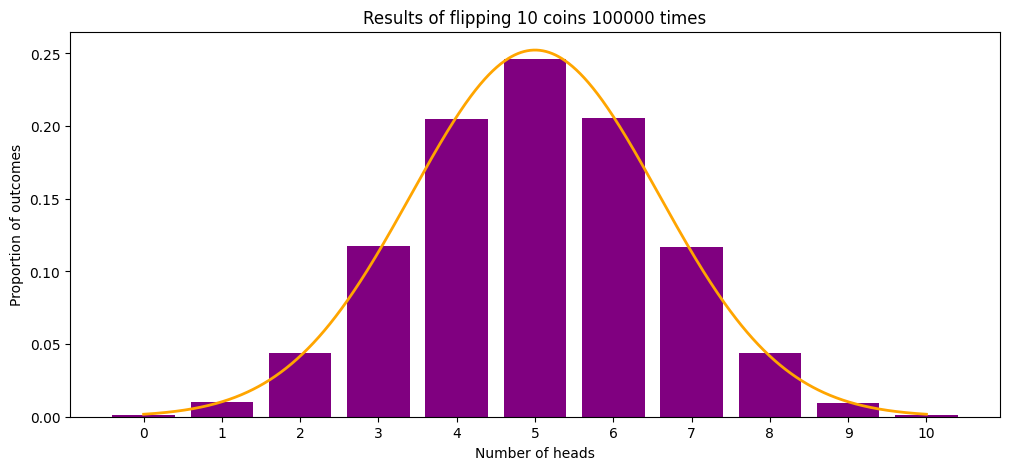

In [80]:
#Number of coins to flip.
n = 10

# Number of times to flip the coins. ie 100,000
k = 100000 * n

# Probability of heads
p = 0.5

# Flip two coins several times.
nflips = np.random.binomial(n, p, size=k)

# Count the number of times each outcome or value occurs.
uniques, counts = np.unique(nflips, return_counts=True)

# Create a blank plot
fig, ax = plt.subplots(figsize=(12, 5))

# create a bar chart with custom colors
# Previously the counts were compared, now we want the proportion of k occured.
# the proportion rather than the total number
# https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html
ax.bar(uniques, counts / k, color='purple')

# Create an x range
x = np.linspace(0, 10, 1001)

# Get the y values
# mu=n*p is where the normal is centred
# sigma=np.sqrt(n*p*(1-p)) is the standard deviation of the binomial distribution
# which is used to set the width of the normal distribution.
# https://numpy.org/doc/2.2/reference/generated/numpy.sqrt.html
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
# https://numpy.org/doc/stable/reference/generated/numpy.pi.html
y = f(x, mu=n*p, sigma=np.sqrt(n*p*(1-p)))

# Plot the function.
ax.plot(x, y, "orange", linewidth=2)

# set x ticks
ax.set_xticks(uniques)

# Add title
ax.set_title(f"Results of flipping {n} coins {k//n} times")

# Add axis labels
ax.set_xlabel("Number of heads")
ax.set_ylabel("Proportion of outcomes")


In [81]:
# Generate 100,000 samples of size 10 from standard normal distribution
# https://stats.libretexts.org/Bookshelves/Introductory_Statistics/Introductory_Statistics_(Shafer_and_Zhang)/06%3A_Sampling_Distributions/6.01%3A_The_Mean_and_Standard_Deviation_of_the_Sample_Mean
n_samples = 100000
sample_size = 10
sample = np.random.normal(0, 1, size=(n_samples, sample_size))

# Compute standard deviations
# samples.std is a function or calculation that finds the sample standard deviation, which measures how spread out a dataset's values are from their average.
#
sd_sample = sample.std(axis=1, ddof=1)      # sample SD (unbiased variance estimator)
sd_population = sample.std(axis=1, ddof=0)  # population SD

### Standard Deviation.

We use a specific formula when calculating the sample standard deviation.

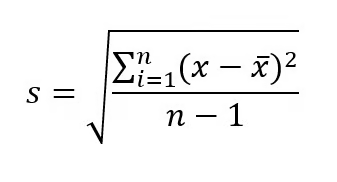


Where:

- **s** = sample standard deviation
- **n** = number of data points in the sample  
- **x** = individual data point
- **x̄** = sample mean
- **n-1** = the correction factor for sample data (Bessel's correction)
Note that when calculating the sample standard deviation, we use n-1 in the denominator to correct the sample bias. This is known as Bessel’s correction. If we were interested in the population standard deviation, we would use n in the denominator instead. 


**How to calculate the standard deviation**
1. Calculate the sample mean
    Add the data point and divide by the number of data points.

2. Find the squared differences from the mean.
    Subtract the mean from each data point and square the result.

3. Sum the squared deviations. 
    Add the results from step 2.

4. Input the variables into the formula above.


Sample standard deviation is a preferred measure of variability when an estimate of the population standard deviation is needed based on a sample. Bessel's correction (n−1) in the formula adjusts the bias and improves the estimate's accuracy since the sample may not perfectly represent the population. Making the denominator smaller increases the calculated variance and standard deviation. This compensates for the tendency of smaller samples to underestimate variability.

https://www.datacamp.com/tutorial/sample-standard-deviation

In [82]:
# Print summary statistics
print("Summary (mean ± std of SD's):")
print(f" Sample SD (ddof=1): mean = {sd_sample.mean():.6f}, std = {sd_sample.std(ddof=0):.6f}")
print(f" Population SD (ddof=0): mean = {sd_population.mean():.6f}, std = {sd_population.std(ddof=0):.6f}")


Summary (mean ± std of SD's):
 Sample SD (ddof=1): mean = 0.973772, std = 0.232407
 Population SD (ddof=0): mean = 0.923801, std = 0.220481


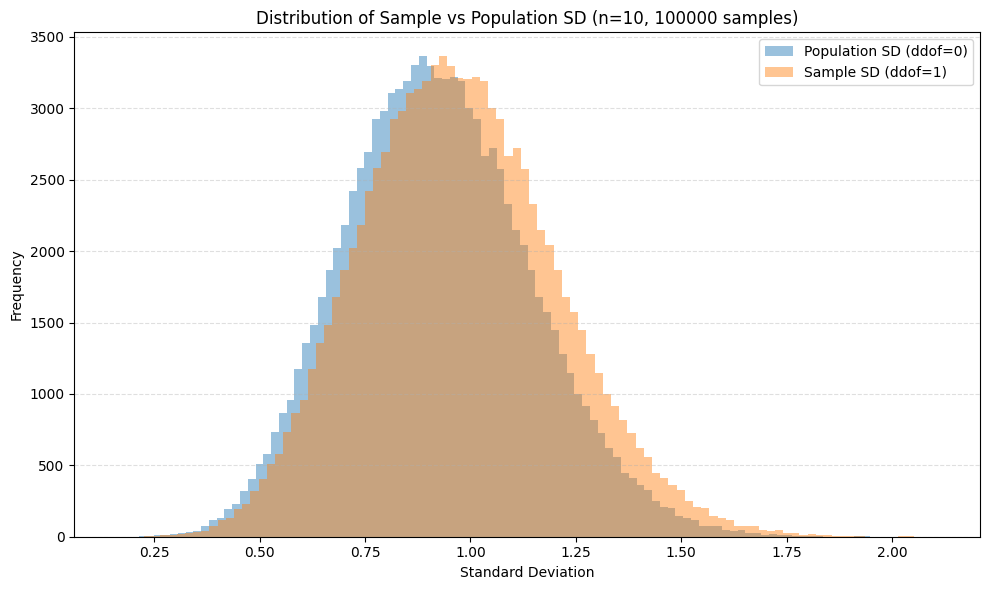

In [83]:
# Plot histograms on same axes
plt.figure(figsize=(10, 6))
plt.hist(sd_population, bins=100, alpha=0.45, label='Population SD (ddof=0)', density=False)
plt.hist(sd_sample, bins=100, alpha=0.45, label='Sample SD (ddof=1)', density=False)
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")
plt.title(f"Distribution of Sample vs Population SD (n={sample_size}, {n_samples} samples)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

- The **sample SD** distribution is slightly shifted right.
- This is because sample SD divides by *n-1* instead of *n*, making it a larger quantity on average.
- The difference is noticeable when the sample size is small.

### Behavior for Larger Sample Sizes
When repeating the computation for larger sample sizes:
- n = 10 (orig)
- n = 30
- n = 100
What happens to the two distributions as n increases?

In [84]:
sample_sizes = [10, 30, 100]
results = {}

for n in sample_sizes:
    data = np.random.normal(size=(n_samples, n))
    sd_s = data.std(axis=1, ddof=1)
    sd_p = data.std(axis=1, ddof=0)
    results[n] = (sd_s, sd_p)
    print(f"n={n}: mean sd_sample={sd_s.mean():.4f}, mean sd_population={sd_p.mean():.4f}")

n=10: mean sd_sample=0.9734, mean sd_population=0.9235
n=30: mean sd_sample=0.9915, mean sd_population=0.9748
n=100: mean sd_sample=0.9975, mean sd_population=0.9925


### Plot comparason for n = 30 and n = 100

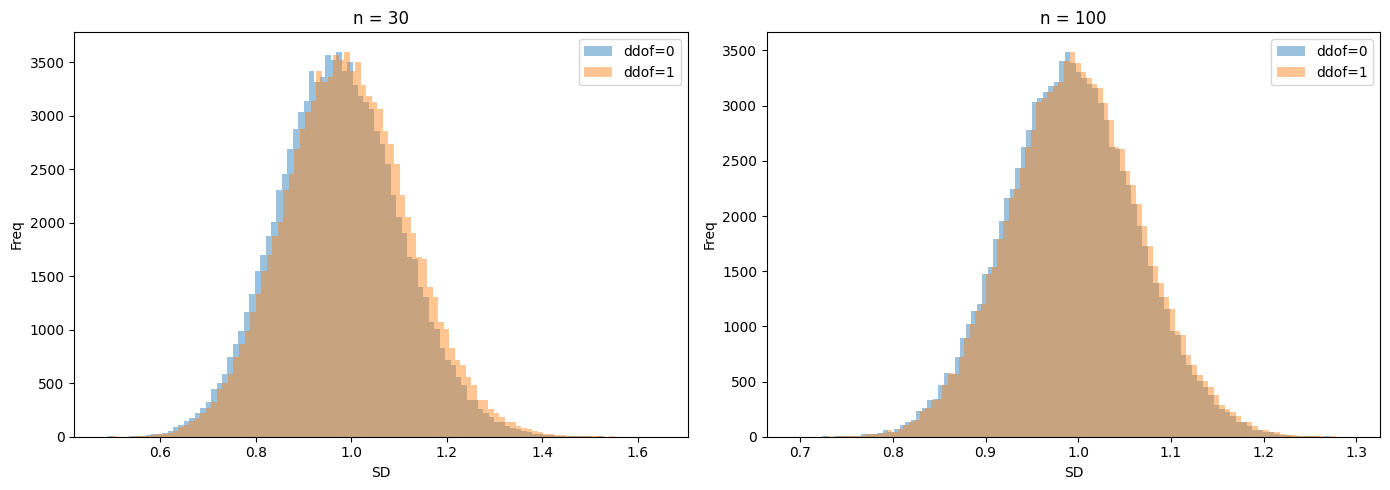

In [85]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))

for ax, n in zip(axs, [30, 100]):
    sd_s, sd_p = results[n]
    ax.hist(sd_p, bins=100, alpha=0.45, label='ddof=0')
    ax.hist(sd_s, bins=100, alpha=0.45, label='ddof=1')
    ax.set_title(f"n = {n}")
    ax.set_xlabel("SD")
    ax.set_ylabel("Freq")
    ax.legend()

plt.tight_layout()
plt.show()

### Shapiro-Wilk test for normality
The Shapiro–Wilk test tests the null hypothesis that a sample x₁, ..., xₙ came from a normally distributed population. The test statistic is:

$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

where:

- $x_{(i)}$ is the i-th order statistic (the i-th smallest value in the sample)
- $\bar{x} = \frac{x_1 + \cdots + x_n}{n}$ is the sample mean
- The coefficients $a_i$ are given by:

$$(a_1, \ldots, a_n) = \frac{m^T V^{-1}}{C}$$

where $C$ is the vector norm:

$$C = \|V^{-1}m\| = \left(m^T V^{-1} V^{-1} m\right)^{1/2}$$

and the vector $m = (m_1, \ldots, m_n)^T$ contains the expected values of the order statistics from the standard normal distribution, while $V$ is the covariance matrix of those normal order statistics.

<b>The null-hypothesis of this test is that the population is normally distributed.</b> If the p value is less than the chosen alpha level, then the null hypothesis is rejected and there is evidence that the data tested are not normally distributed

https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test

The Shapiro-Wilk test is more appropriate for sample sizes <50 but can handle sample sizes as large as 2000

https://www.spss-tutorials.com/spss-shapiro-wilk-test-for-normality/


In [86]:
# perform Shapiro-Wilk test for normality
# https://docs.scipy.org/doc/scipy-1.16.2/tutorial/stats/hypothesis_shapiro.html
stats.shapiro(data)

/home/codespace/.local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000000.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9999997757787498), pvalue=np.float64(1.0))

The above tells us that the probability (p value) of seeing the above result is 100%. pvalue=np.float64(1.0). 

###  Analysis

When presented with a small sample size ie a small number of coins, the binomial is jagged. As the sample size increases ie the number of coins increases the binomial resembles a smooth normal bell curve. The mean is $np$ and the SD is $\sqrt{np(1-p)}$.

- For **n = 30**, the two distributions are much closer.
- For **n = 100**, they are nearly identical.

As n increases:
- The factor \( n/(n-1) \) approaches 1.
- Sampling variability decreases.
- Both estimators cluster more tightly around the true SD = 1.

The Shapiro Wilks test doesn't provide any evidence that the data are not normally distributed and there is no evidence that the null hypothesis should be rejected.


<img src="https://media1.tenor.com/m/Z8bTkI7qkVUAAAAC/guinness-real.gif" alt="Guinness GIF" style="display: block; margin: 0 auto; max-width: 100%;">

## Problem 3: t-Tests

A type II error occurs when a test fails to reject the null hypothesis even though it is false. For each mean difference $d = 0, 0.1, 0.2, \ldots, 1.0$, repeat the following simulation 1,000 times:

1. Draw two samples of size 100, one from the standard normal distribution and one from the normal distribution with mean 
d
 and standard deviation 
2. Run an independent samples t-test on the two samples, rejecting the null hypothesis if the p-value is less than 0.05.
3. Record the proportion of times the null hypothesis is not rejected.

Plot this proportion against 
d
, and explain how the type II error rate changes as the difference in means increases.

https://github.com/ianmcloughlin/applied-statistics/blob/main/assessment/problems.md

### William Sealy Gosset
William Sealy Gosset (13 June 1876 – 16 October 1937) was an English statistician, chemist and brewer who worked for Guinness. In statistics, he pioneered small sample experimental design. Gosset published under the pen name <b>Student</b> and developed Student's t-distribution – originally called Student's "z" – and "Student's test of statistical significance".

Upon graduating in 1899, he joined the brewery of Arthur Guinness & Son in Dublin, Ireland; he spent the rest of his 38-year career at Guinness. In 1904 he wrote an internal report for Guiness titled "The application of the law of error to work of the brewery". He had conducted experiments with only small sample sizes and was aware that analysis was difficult, hence he recommended consulting mathematicians who were knowledgeable in probability theory. In 1906-1907, Guinness sent him to Karl Pearson's laboratory at University College London for two terms

In his job as Head Experimental Brewer at Guinness, Gosset developed new statistical methods – both in the brewery and on the farm – now central to the design of experiments, to proper use of significance testing on repeated trials, and to analysis of economic significance (an early instance of decision theory interpretation of statistics) and more, such as his small-sample, stratified, and repeated balanced experiments on barley for proving the best yielding varieties.Gosset acquired that knowledge by study, by trial and error, and by cooperating with others.

https://en.wikipedia.org/wiki/William_Sealy_Gosset

### Type I and Type II errors
Type I error, or a false positive, is the incorrect rejection of a true null hypothesis in statistical hypothesis testing. A type II error, or a false negative, is the incorrect failure to reject a false null hypothesis.

Type I errors can be thought of as errors of commission, in which the status quo is incorrectly rejected in favour of new, misleading information.

Type II errors can be thought of as errors of omission, in which a misleading status quo is allowed to remain due to failures in identifying it as such.


Knowledge of type I errors and type II errors is applied widely in fields of in medical science, biometrics and computer science. Minimising these errors is an object of study within statistical theory, though complete elimination of either is impossible when relevant outcomes are not determined by known, observable, causal processes.

https://en.wikipedia.org/wiki/Type_I_and_type_II_errors


### Students t-test

Student's t-test is a statistical test used to test whether the difference between the response of two groups is statistically significant or not. It is any statistical hypothesis test in which the test statistic follows a Student's t-distribution under the null hypothesis. It is most commonly applied when the test statistic would follow a normal distribution if the value of a scaling term in the test statistic were known (typically, the scaling term is unknown and is therefore a nuisance parameter). When the scaling term is estimated based on the data, the test statistic—under certain conditions—follows a Student's t distribution. The t-test's most common application is to test whether the means of two populations are significantly different. In many cases, a Z-test will yield very similar results to a t-test because the latter converges to the former as the size of the dataset increases.

https://en.wikipedia.org/wiki/Student%27s_t-test



### Nornal Samples
https://numpy.org/devdocs/reference/random/generated/numpy.random.normal.html

In [87]:
# Group A
group_a = np.random.normal(loc=5.0, scale=2.0, size=30)

# Group B
group_b = np.random.normal(loc=5.0, scale=2.0, size=30)

# Show
group_a, group_b

(array([1.9336478 , 5.31894602, 4.44450152, 7.81339791, 3.84101277,
        3.53378887, 2.55301507, 4.0623044 , 3.8828756 , 6.45849792,
        7.41702966, 5.50214811, 3.42232031, 6.53247561, 0.11619782,
        4.86048013, 6.32331284, 7.15629372, 4.4041878 , 7.58665846,
        6.76613445, 4.32977363, 0.66962671, 4.80594033, 1.78648376,
        4.99009156, 3.38855481, 2.13105986, 3.02928457, 0.71400306]),
 array([5.71063873, 7.54687152, 7.26035039, 5.76303626, 5.04972533,
        5.03587291, 8.355921  , 5.36619415, 5.64281357, 5.15231666,
        2.68263172, 8.41509886, 6.8012098 , 5.09988067, 3.55893278,
        7.49090125, 7.94344849, 2.97352811, 8.26738102, 6.59498094,
        0.30239703, 4.9119888 , 7.09997529, 5.15618537, 2.5745024 ,
        7.02291943, 3.70879583, 3.84352701, 4.83618714, 5.24034943]))

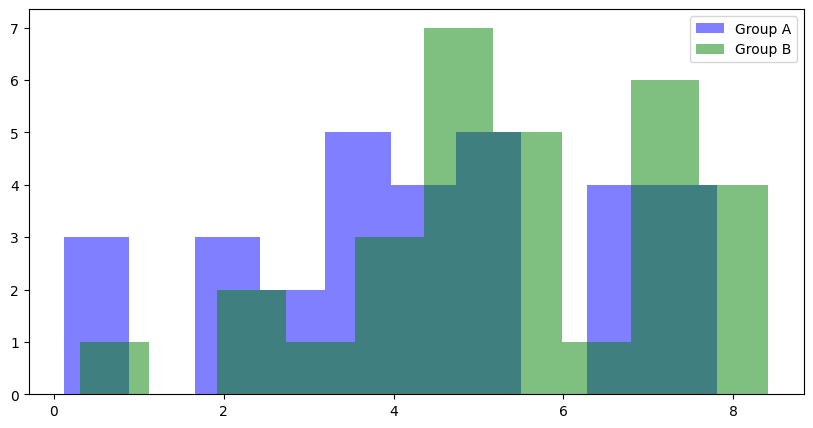

In [ ]:
# Create an empty plot
# https://matplotlib.org/stable/gallery/statistics/histogram_multihist.html#sphx-glr-gallery-statistics-histogram-multihist-py
fig, ax = plt.subplots(figsize =(10, 5))

# create histogram for group A
# alpha is transparency. 0 is fully transparent, 1 is fully opaque.
ax.hist(group_a, alpha=0.5, label='Group A', color='blue', bins=10)

# create histogram for group B
ax.hist(group_b, alpha=0.5, label='Group B', color='green', bins=10)

# add legend
ax.legend()

<Axes: >

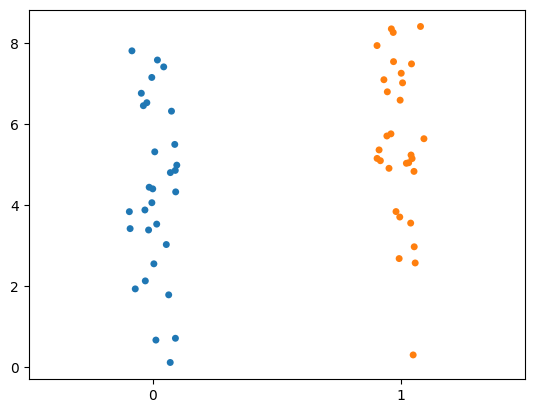

In [ ]:
# create a strip plot to show individual data points
# https://seaborn.pydata.org/generated/seaborn.stripplot.html
# The points are jittered to avoid overplotting. 
sns.stripplot(data=[group_a, group_b])

<Axes: >

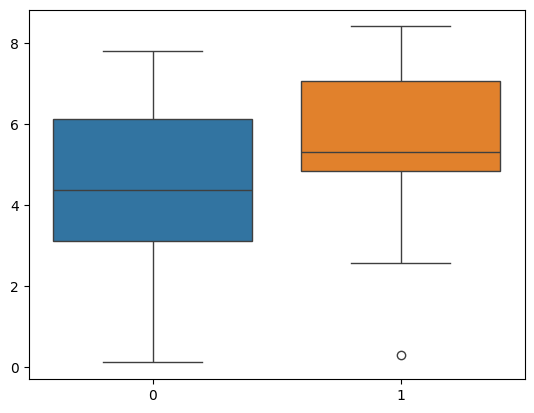

In [91]:
# box plot to show summary statistics
# https://seaborn.pydata.org/generated/seaborn.boxplot.html
sns.boxplot(data=[group_a, group_b])

The box plot is sometimes called the whisker plot. The top part of the box is the 75th centile and the bottom part of the box is the 25th centile. The whiskers are the difference between the 75th and the 25th centile. Can also be called the interquartile range.  

### Independant Samples <i>t</i>-Test

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

Null Hypotheesis: the population means are equal

Independant samples are where the figures in one group are not necessarily related to the samples in another group

In [92]:
# perform a t-test
stats.ttest_ind(group_a, group_b)

TtestResult(statistic=np.float64(-2.2494756038473516), pvalue=np.float64(0.02829322499550152), df=np.float64(58.0))

The value 

### Paired Samples <i>t</i>-Test 

Paired samples are where you measure a group before an intervention and then you measure the same group after the intervention. The difference in scores is what is looked at in a paired sample.

In [ ]:
# A group of normally distributed values

insert appropriate image or GIF here

## Problem 4: ANOVA

Generate three independent samples, each of size 30, from normal distributions with means 0, 0.5, and 1, each with standard deviation 1.

Perform a one-way ANOVA to test whether all three means are equal.
Perform three independent two-sample t-tests: samples 1 vs 2, 1 vs 3, and 2 vs 3.
Compare the conclusions.
Write a short note on why ANOVA is preferred over running several t-tests.

https://github.com/ianmcloughlin/applied-statistics/blob/main/assessment/problems.md

Analysis of variance (ANOVA) is a family of statistical methods used to compare the means of two or more groups by analyzing variance. Specifically, ANOVA compares the amount of variation between the group means to the amount of variation within each group. If the between-group variation is substantially larger than the within-group variation, it suggests that the group means are likely different. This comparison is done using an F-test. The underlying principle of ANOVA is based on the law of total variance, which states that the total variance in a dataset can be broken down into components attributable to different sources. In the case of ANOVA, these sources are the variation between groups and the variation within groups.

ANOVA was developed by the statistician Ronald Fisher. In its simplest form, it provides a statistical test of whether two or more population means are equal, and therefore generalizes the t-test beyond two means.

https://en.wikipedia.org/wiki/Analysis_of_variance

An F-test is a statistical test that compares variances. It is used to determine if the variances of two samples, or if the ratios of variances among multiple samples, are significantly different. The test calculates a statistic, represented by the random variable F, and checks if it follows an F-distribution. This check is valid if the null hypothesis is true and standard assumptions about the errors (ε) in the data hold.

F-tests are frequently used to compare different statistical models and find the one that best describes the population the data came from. When models are created using the least squares method, the resulting F-tests are often called "exact" F-tests. The F-statistic was developed by Ronald Fisher in the 1920s as the variance ratio and was later named in his honor by George W. Snedecor.

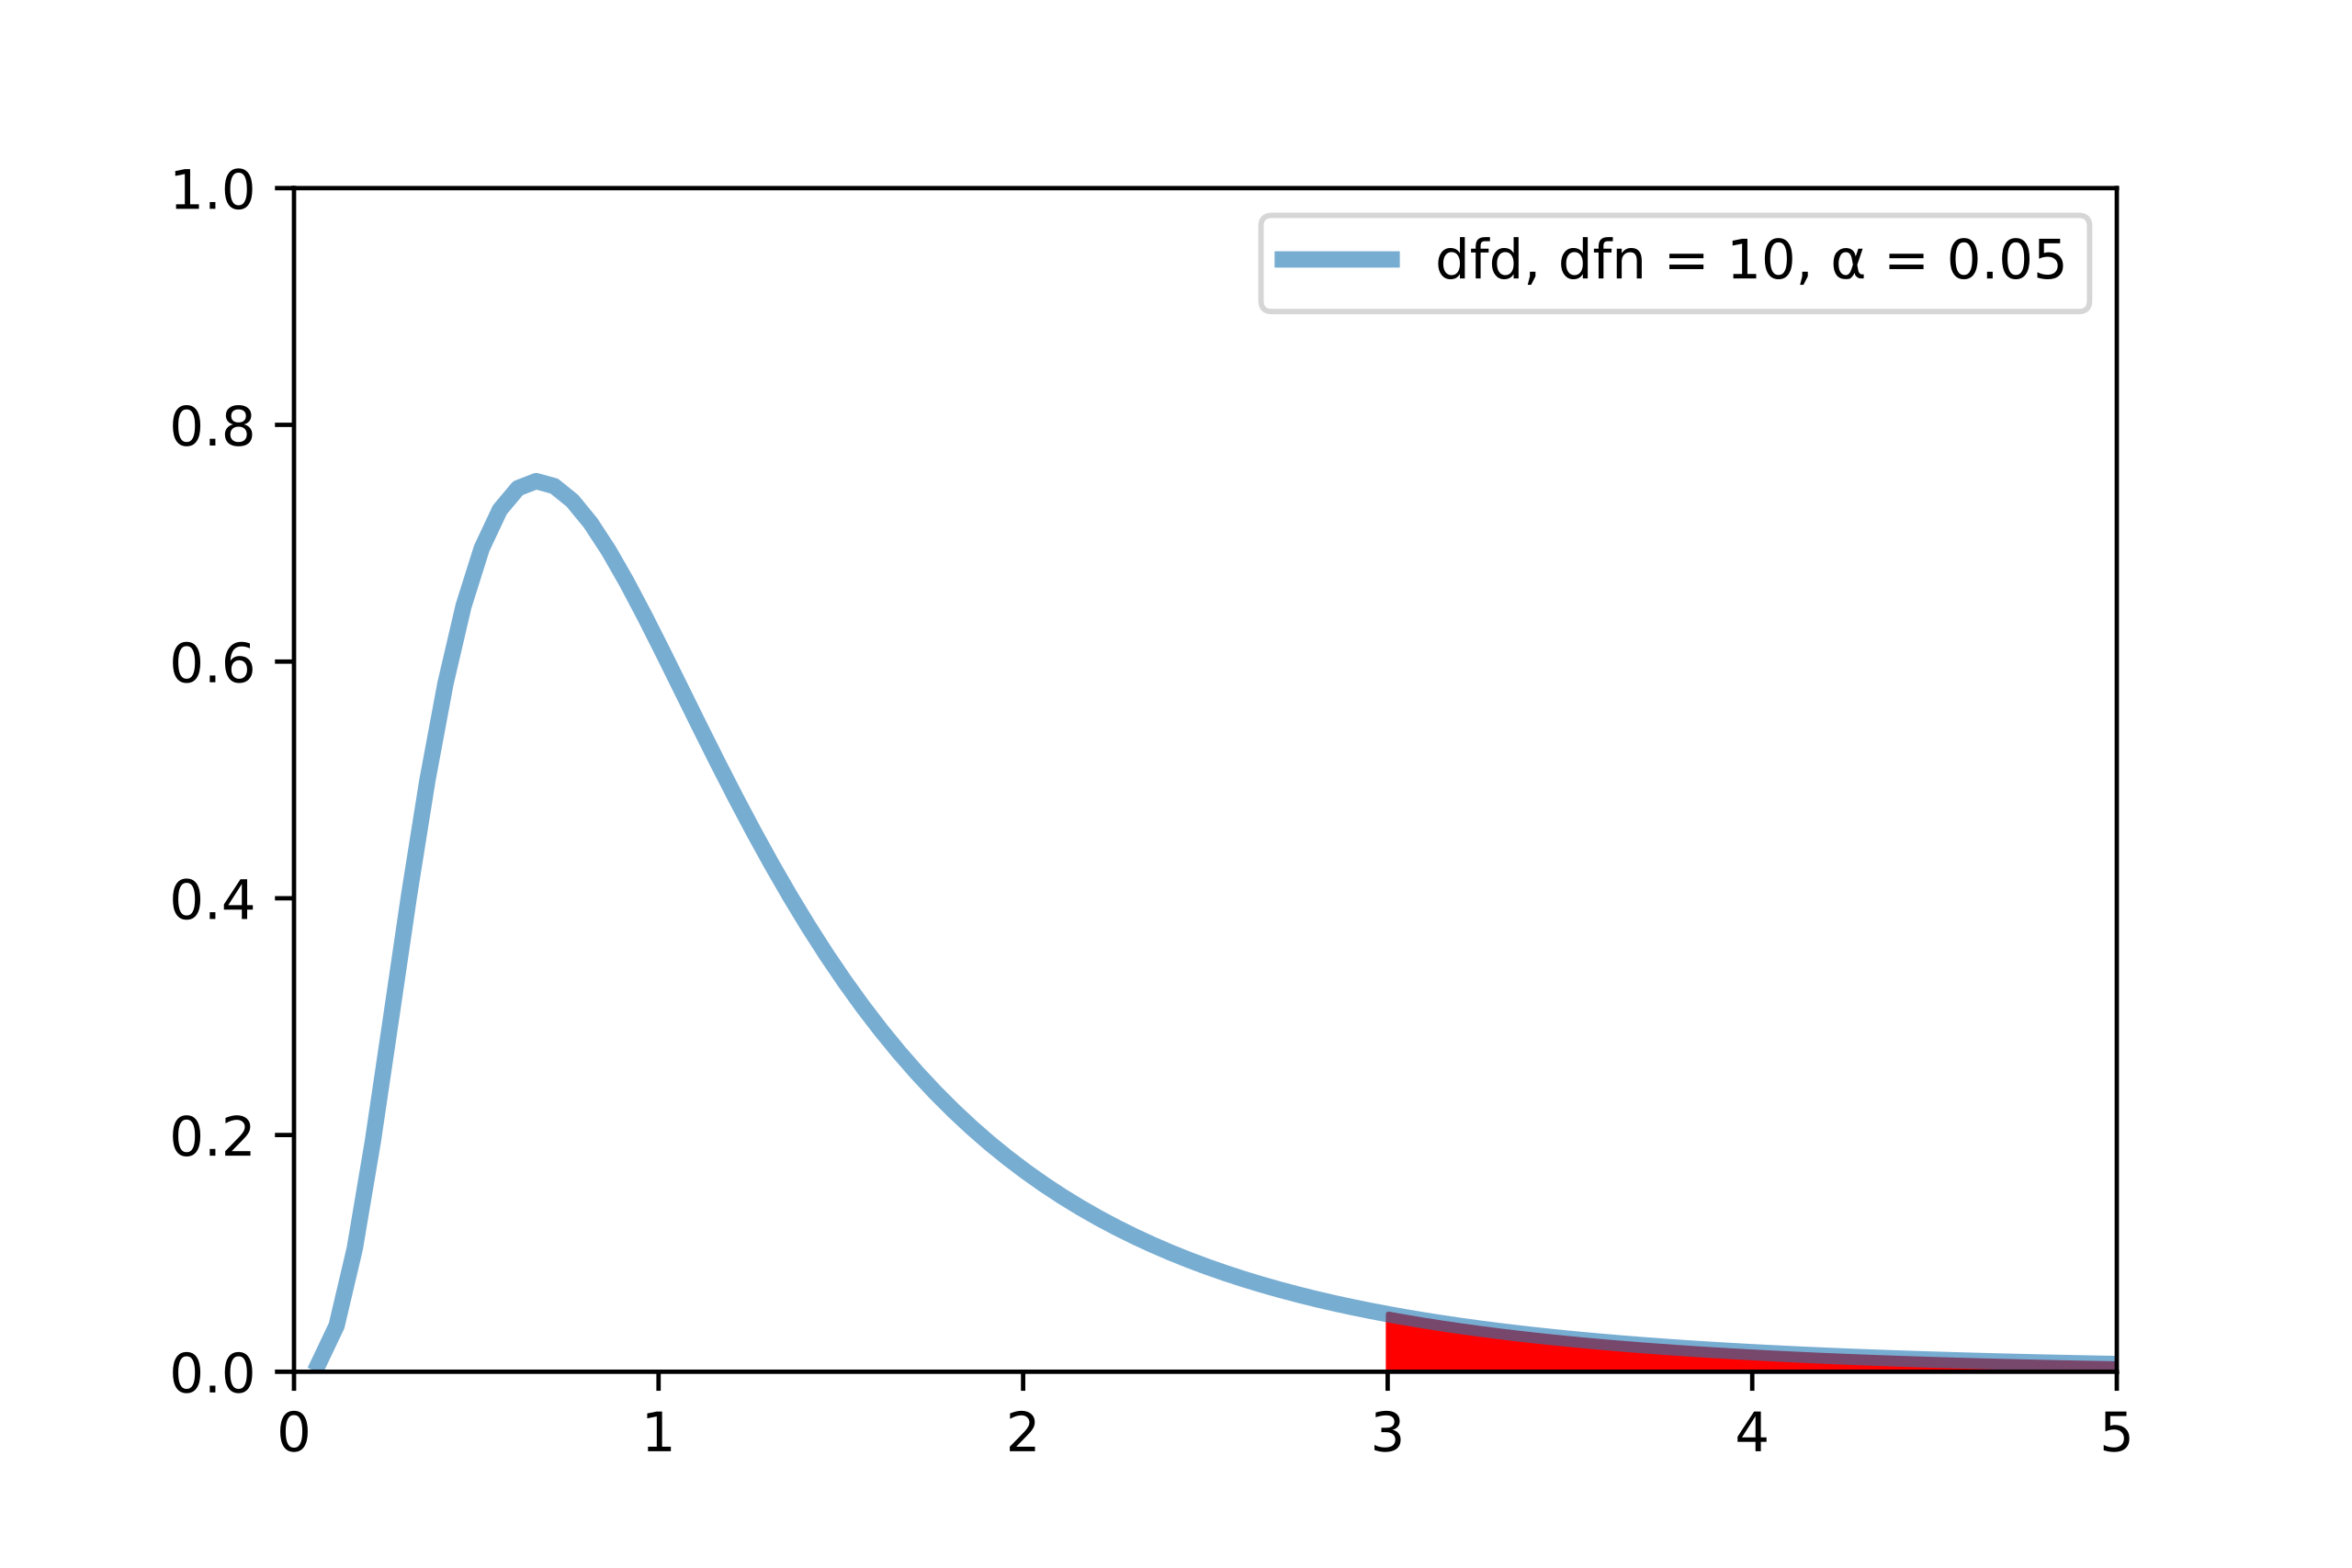

An F-test pdf with d1 and d2 = 10, at a significance level of 0.05. (Red shaded region indicates the critical region)

https://en.wikipedia.org/wiki/F-test

## END